# Pakistan 24K Gold Price — 30-Day ML Forecast

**Pipeline**

1. Load the `Daily_Regression` sheet, drop redundant / leaking columns, clean without leakage
2. Engineer lags, rolling means, rolling standard deviations and calendar features
3. Visualise the trend and the feature correlations
4. Train and tune six models with a chronological 80/20 split
5. Recursive 30-day forecast with the best model, then export everything to `Pakistan_Gold_30_Day_ML_Final.xlsx`

**Requirements:** `pandas numpy matplotlib seaborn scikit-learn openpyxl`

---

### Read this first: how accuracy is measured

* Every metric is computed on the **held-out chronological test set** (the most recent 20 % of days). Nothing is tuned or scored on the same rows it was trained on.
* Models predict the **next-day log-return**, and the price is rebuilt as `yesterday's price × exp(predicted return)`. Tree models cannot extrapolate beyond price levels seen in training, so predicting the raw price level fails whenever gold trends into new territory (this is why tree models scored negative R² in a level-based approach).
* A **naive baseline** ("tomorrow = today") is included in the comparison. Gold prices are very persistent, so *any* model gets a high-looking score just from yesterday's price; the baseline shows how much real skill the ML models add.
* The **target check** in Section 4 reports honestly whether 98 % R² / accuracy was reached. Nothing in this notebook forces or fabricates those numbers.

In [3]:
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

# ---------------- Configuration ----------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SHEET_NAME = "Daily_Regression"
TARGET = "24K_PKR_per_Tola"
LAGS = [1, 2, 3, 7, 14, 30]
WINDOWS = [3, 7, 14, 30]
TEST_FRACTION = 0.20
FORECAST_DAYS = 30
N_ITER = 20                      # random-search iterations per tree model
OUTPUT_XLSX = "Pakistan_Gold_30_Day_ML_Final.xlsx"

FILE_NAME = "Pakistan_Gold_Daily_Regression_2025_to_2026-09-01.xlsx"

## 1. Data cleaning and unwanted-column removal

In [5]:
# Look for the Excel file in the usual places (edit `candidates` if yours lives elsewhere)
candidates = [
    Path(r"C:\Users\DELL\Downloads") / FILE_NAME,
    Path.cwd() / FILE_NAME,
    Path.home() / "Downloads" / FILE_NAME,
    Path("/mnt/user-data/uploads") / FILE_NAME,
]
file_path = next((p for p in candidates if p.exists()), None)

if file_path is None:  # fall back to any similarly named workbook
    hits = list(Path.cwd().glob("Pakistan_Gold_Daily_Regression*.xlsx")) + \
           list((Path.home() / "Downloads").glob("Pakistan_Gold_Daily_Regression*.xlsx"))
    file_path = hits[0] if hits else None

if file_path is None:
    raise FileNotFoundError(
        f"Could not find '{FILE_NAME}'. Put it next to this notebook or add its path to `candidates`."
    )

raw = pd.read_excel(file_path, sheet_name=SHEET_NAME)
print("Loaded  :", file_path)
print("Shape   :", raw.shape)
print("Columns :", list(raw.columns))

# Disclosure: how much of the sheet is forward-filled (weekends / holidays), before the flag is dropped
if "Is_Observed" in raw.columns:
    print(f"\nForward-filled rows (no fresh quote that day): {(raw['Is_Observed'] == 0).mean() * 100:.1f}%")

Loaded  : C:\Users\DELL\Downloads\Pakistan_Gold_Daily_Regression_2025_to_2026-09-01.xlsx
Shape   : (609, 8)
Columns : ['Date', 'Day_of_Week', 'Day_of_Week_Num', '24K_PKR_per_Tola', '24K_Daily_Change_PKR', '24K_Daily_Change_Pct', 'Is_Observed', 'Fill_Basis_Date']

Forward-filled rows (no fresh quote that day): 12.2%


In [6]:
# Columns removed, and why
DROP_REASONS = {
    "Day_of_Week":          "Text label; redundant (a numeric weekday is recomputed from Date)",
    "Day_of_Week_Num":      "Redundant; recomputed from Date so the encoding is consistent (Mon=1 ... Sun=7)",
    "24K_Daily_Change_PKR": "LEAKAGE: same-day price minus previous price (contains today's target)",
    "24K_Daily_Change_Pct": "LEAKAGE: same-day % change (contains today's target)",
    "Is_Observed":          "Bookkeeping flag about forward-filling; not a market variable",
    "Fill_Basis_Date":      "Bookkeeping date used for forward-filling; not a market variable",
}

keep_cols = ["Date", TARGET]
extra_cols = [c for c in raw.columns if c not in keep_cols and c not in DROP_REASONS]
dropped_cols = [c for c in raw.columns if c not in keep_cols]

dropped_df = pd.DataFrame({
    "Dropped_Column": dropped_cols,
    "Reason": [DROP_REASONS.get(c, "Not needed: only the date and the price are kept") for c in dropped_cols],
})
display(dropped_df)

df = raw[keep_cols].copy()
print("Remaining columns:", list(df.columns))

,Dropped_Column,Reason
0,Day_of_Week,Text label; redundant (a numeric weekday is re...
1,Day_of_Week_Num,Redundant; recomputed from Date so the encodin...
2,24K_Daily_Change_PKR,LEAKAGE: same-day price minus previous price (...
3,24K_Daily_Change_Pct,LEAKAGE: same-day % change (contains today's t...
4,Is_Observed,Bookkeeping flag about forward-filling; not a ...
5,Fill_Basis_Date,Bookkeeping date used for forward-filling; not...


Remaining columns: ['Date', '24K_PKR_per_Tola']


In [7]:
# ---- Cleaning (every step uses PAST information only, so nothing leaks from the future) ----
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df.loc[df[TARGET] <= 0, TARGET] = np.nan            # a gold price can never be <= 0

n_bad_dates = int(df["Date"].isna().sum())
df = df.dropna(subset=["Date"]).sort_values("Date")

n_dupes = int(df["Date"].duplicated().sum())
df = df.drop_duplicates(subset="Date", keep="last")

# Put the series on a complete daily calendar so every lag means exactly "k days ago"
full_range = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
df = df.set_index("Date").reindex(full_range).rename_axis("Date")
n_missing = int(df[TARGET].isna().sum())

# Forward-fill ONLY. Backward-fill / interpolation / mean-imputation would use future prices.
df[TARGET] = df[TARGET].ffill()
df = df.dropna(subset=[TARGET]).reset_index()

print(f"Unparseable dates dropped : {n_bad_dates}")
print(f"Duplicate dates removed   : {n_dupes}")
print(f"Missing prices forward-filled: {n_missing}")
print(f"Clean rows                : {len(df)}  ({df['Date'].min().date()} -> {df['Date'].max().date()})")

daily_move = df[TARGET].pct_change().abs() * 100
print(f"Largest one-day move      : {daily_move.max():.2f}%  (review if this looks unrealistic)")
df.head()

Unparseable dates dropped : 0
Duplicate dates removed   : 0
Missing prices forward-filled: 0
Clean rows                : 609  (2025-01-01 -> 2026-09-01)
Largest one-day move      : 8.14%  (review if this looks unrealistic)


,Date,24K_PKR_per_Tola
0,2025-01-01,292000.0
1,2025-01-02,290000.0
2,2025-01-03,290500.0
3,2025-01-04,290500.0
4,2025-01-05,290500.0


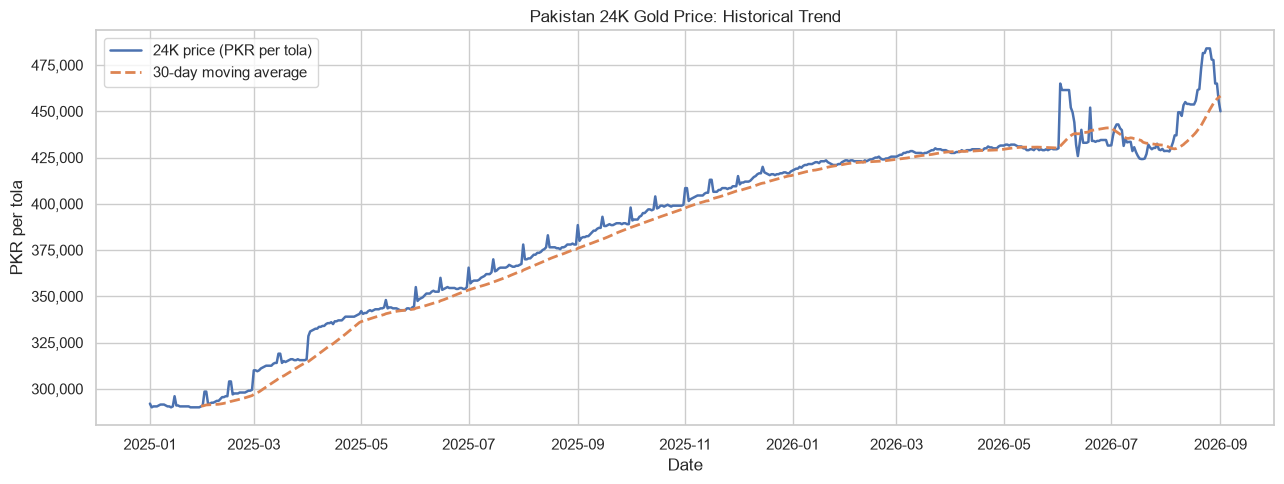

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["Date"], df[TARGET], lw=1.8, label="24K price (PKR per tola)")
ax.plot(df["Date"], df[TARGET].rolling(30).mean(), lw=2, ls="--", label="30-day moving average")
ax.set(title="Pakistan 24K Gold Price: Historical Trend", xlabel="Date", ylabel="PKR per tola")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

## 2. Feature engineering

All rolling features are computed on the price **shifted by one day**, so a row only ever sees days *before* it.

* **Requested features:** `Lag_1/2/3/7/14/30`, `MA_3/7/14/30`, `Std_3/7/14/30`, and the calendar features `Day_of_Week_Num`, `Month`, `Day_of_Month`, `Is_Weekend`.
* **Scale-free versions (used by the models):** momentum (`Lag_1 / Lag_k − 1`), distance from each moving average (`Lag_1 / MA_w − 1`) and relative volatility (`Std_w / MA_w`). They describe *what the market is doing* rather than *where the price level is*, so the same relationship holds at 300k PKR and at 480k PKR.

In [10]:
RAW_LAG = [f"Lag_{k}" for k in LAGS]
RAW_MA  = [f"MA_{w}" for w in WINDOWS]
RAW_STD = [f"Std_{w}" for w in WINDOWS]
CAL     = ["Day_of_Week_Num", "Month", "Day_of_Month", "Is_Weekend"]


def add_calendar(frame):
    frame = frame.copy()
    dow = frame["Date"].dt.dayofweek
    frame["Day_of_Week_Num"] = dow + 1              # Monday=1 ... Sunday=7 (same as the source sheet)
    frame["Month"] = frame["Date"].dt.month
    frame["Day_of_Month"] = frame["Date"].dt.day
    frame["Is_Weekend"] = (dow >= 5).astype(int)
    return frame


def add_relative_features(frame):
    frame = frame.copy()
    for k in [2, 3, 7, 14, 30]:
        frame[f"Mom_{k}"] = frame["Lag_1"] / frame[f"Lag_{k}"] - 1
    for w in WINDOWS:
        frame[f"Dev_MA_{w}"] = frame["Lag_1"] / frame[f"MA_{w}"] - 1
        frame[f"Vol_{w}"] = frame[f"Std_{w}"] / frame[f"MA_{w}"]
    return frame


# ---------- vectorised features for the historical data ----------
feat = df.copy()
price = feat[TARGET].astype(float)

for k in LAGS:
    feat[f"Lag_{k}"] = price.shift(k)

past = price.shift(1)                                # yesterday and earlier only
for w in WINDOWS:
    feat[f"MA_{w}"] = past.rolling(w).mean()
for w in WINDOWS:
    feat[f"Std_{w}"] = past.rolling(w).std()

feat = add_calendar(feat)
feat = add_relative_features(feat)
feat["Target_LogReturn"] = np.log(feat[TARGET] / feat["Lag_1"])

rows_before = len(feat)
feat = feat.dropna().reset_index(drop=True)          # removes only the first 30 warm-up rows
print(f"Rows after building features: {len(feat)}  (dropped {rows_before - len(feat)} warm-up rows)")

REL_FEATURES = ([f"Mom_{k}" for k in [2, 3, 7, 14, 30]]
                + [f"Dev_MA_{w}" for w in WINDOWS]
                + [f"Vol_{w}" for w in WINDOWS])
RAW_FEATURES = RAW_LAG + RAW_MA + RAW_STD + CAL
MODEL_FEATURES = REL_FEATURES + CAL                  # what the models actually train on
print("Model features:", len(MODEL_FEATURES), "->", MODEL_FEATURES)

feat[["Date", TARGET] + RAW_LAG[:3] + RAW_MA[:2] + RAW_STD[:2] + CAL].tail()

Rows after building features: 579  (dropped 30 warm-up rows)
Model features: 17 -> ['Mom_2', 'Mom_3', 'Mom_7', 'Mom_14', 'Mom_30', 'Dev_MA_3', 'Dev_MA_7', 'Dev_MA_14', 'Dev_MA_30', 'Vol_3', 'Vol_7', 'Vol_14', 'Vol_30', 'Day_of_Week_Num', 'Month', 'Day_of_Month', 'Is_Weekend']


,Date,24K_PKR_per_Tola,Lag_1,Lag_2,Lag_3,MA_3,MA_7,Std_3,Std_7,Day_of_Week_Num,Month,Day_of_Month,Is_Weekend
574,2026-08-28,477700.0,478000.0,484000.0,484000.0,482000.000000,480857.142857,3464.101615,4089.766555,5,8,28,0
575,2026-08-29,465000.0,477700.0,478000.0,484000.0,479900.000000,481528.571429,3553.871129,2751.795950,6,8,29,1
576,2026-08-30,465000.0,465000.0,477700.0,478000.0,473566.666667,479171.428571,7420.467191,6828.058359,7,8,30,1
577,2026-08-31,455500.0,465000.0,465000.0,477700.0,469233.333333,476814.285714,7332.348419,8526.904200,1,8,31,0
578,2026-09-01,450000.0,455500.0,465000.0,465000.0,461833.333333,472742.857143,5484.827557,10976.316496,2,9,1,0


In [11]:
# ---------- row-by-row feature builder used for the recursive forecast ----------
def build_feature_row(price_history, date):
    """Features for `date`, using ONLY prices up to the day before `date`."""
    p = np.asarray(price_history, dtype=float)
    row = {"Date": date}
    for k in LAGS:
        row[f"Lag_{k}"] = p[-k]
    for w in WINDOWS:
        row[f"MA_{w}"] = p[-w:].mean()
        row[f"Std_{w}"] = p[-w:].std(ddof=1)
    return add_relative_features(add_calendar(pd.DataFrame([row])))


# Consistency check: the row builder must reproduce the vectorised features exactly.
# It also proves no feature uses the current day's price (the builder never sees it).
i = len(df) - 1
check_row = build_feature_row(df[TARGET].values[:i], df["Date"].iloc[i])
cols = RAW_FEATURES + REL_FEATURES
reference = feat.loc[feat["Date"] == df["Date"].iloc[i], cols].iloc[0].astype(float).values
assert np.allclose(check_row[cols].iloc[0].astype(float).values, reference), "Feature builders disagree!"
print("Feature-builder consistency check passed (no look-ahead).")

Feature-builder consistency check passed (no look-ahead).


### Feature correlation heatmaps

The first heatmap uses the requested raw features against the price level, where lags and moving averages are almost perfectly correlated with the price because gold is so persistent. The second uses the scale-free model features against the next-day return, which is a much harder target and shows the real (weak) signal.

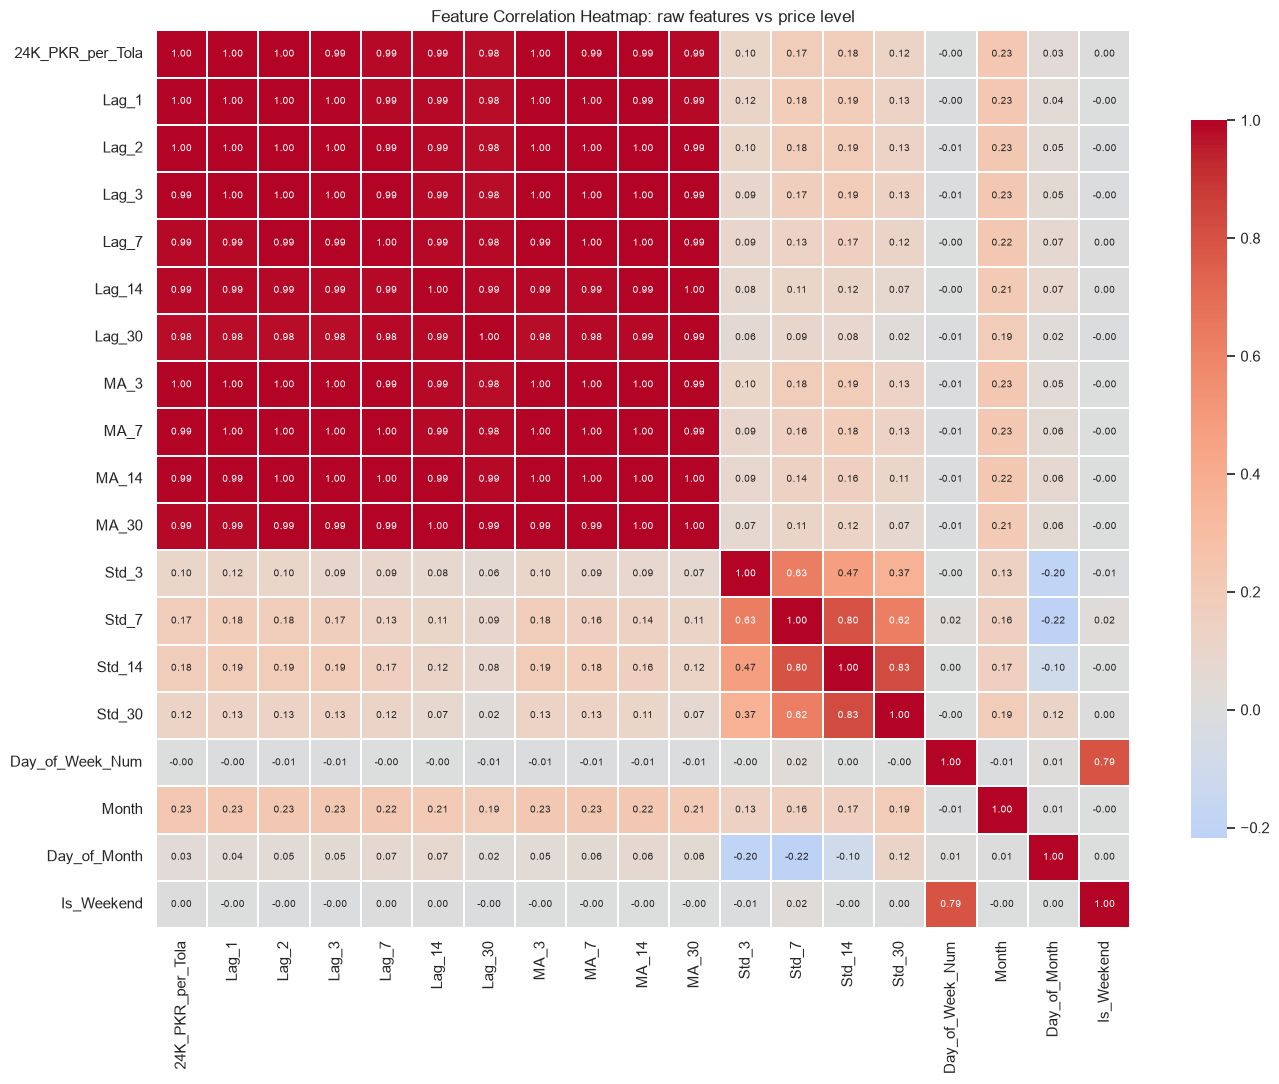

In [12]:
corr_cols = [TARGET] + RAW_LAG + RAW_MA + RAW_STD + CAL
plt.figure(figsize=(14, 11))
sns.heatmap(feat[corr_cols].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap: raw features vs price level")
plt.tight_layout()
plt.show()

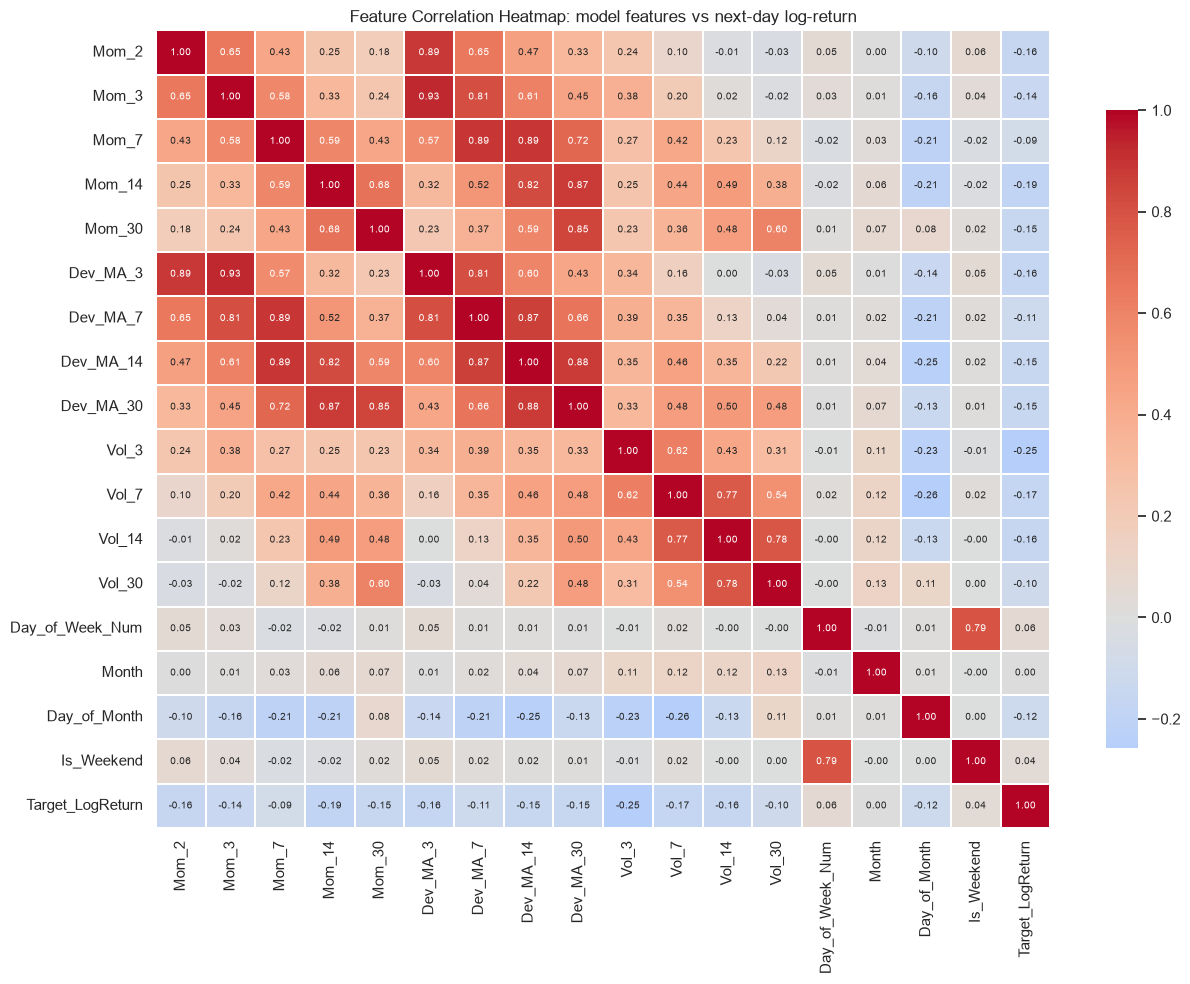

In [13]:
plt.figure(figsize=(13, 10))
sns.heatmap(feat[MODEL_FEATURES + ["Target_LogReturn"]].corr(), cmap="coolwarm", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 7}, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap: model features vs next-day log-return")
plt.tight_layout()
plt.show()

## 3. Chronological train / test split (80 / 20)

No shuffling: the model is trained on the past and tested on the most recent days.

In [24]:
split = int(len(feat) * (1 - TEST_FRACTION))
train, test = feat.iloc[:split], feat.iloc[split:]

X_train, y_train = train[MODEL_FEATURES], train["Target_LogReturn"]
X_test,  y_test  = test[MODEL_FEATURES],  test["Target_LogReturn"]

price_test = test[TARGET].values          # actual prices in the test window
lag1_test  = test["Lag_1"].values         # yesterday's actual price (one-step-ahead evaluation)

print(f"Train: {len(train)} rows | {train['Date'].min().date()} -> {train['Date'].max().date()}")
print(f"Test : {len(test)} rows | {test['Date'].min().date()} -> {test['Date'].max().date()}")
print(f"Train price range: {train[TARGET].min():,.0f} - {train[TARGET].max():,.0f}")
print(f"Test  price range: {test[TARGET].min():,.0f} - {test[TARGET].max():,.0f}")

Train: 463 rows | 2025-01-31 -> 2026-05-08
Test : 116 rows | 2026-05-09 -> 2026-09-01
Train price range: 291,000 - 432,000
Test  price range: 424,200 - 484,000


## 4. Model building, hyperparameter tuning and comparison

Six models are compared. Ridge and the four tree models are tuned with `TimeSeriesSplit` cross-validation **inside the training set only**, so the test set is never used for tuning. Linear models sit in a pipeline with a `StandardScaler`, which is fitted on training folds only.

In [25]:
cv = TimeSeriesSplit(n_splits=5)


def scaled(model):
    return Pipeline([("scale", StandardScaler()), ("model", model)])


tree_space = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 5, 8, 12, None],
    "min_samples_leaf": [1, 3, 5, 10, 20],
    "max_features": [0.4, 0.6, 0.8, 1.0],
}

search_plan = {
    "Linear Regression": {"estimator": scaled(LinearRegression()), "params": None},
    "Ridge Regression": {
        "estimator": scaled(Ridge()),
        "params": {"model__alpha": np.logspace(-3, 5, 33)},
        "search": "grid",
    },
    "Random Forest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE),
        "params": tree_space, "search": "random",
    },
    "Extra Trees": {
        "estimator": ExtraTreesRegressor(random_state=RANDOM_STATE),
        "params": tree_space, "search": "random",
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": [100, 200, 400],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_depth": [2, 3, 4],
            "subsample": [0.7, 0.85, 1.0],
            "min_samples_leaf": [1, 5, 10, 20],
        },
        "search": "random",
    },
    "HistGradientBoosting": {
        "estimator": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "max_iter": [100, 200, 400],
            "learning_rate": [0.01, 0.03, 0.05, 0.1],
            "max_depth": [None, 3, 5],
            "min_samples_leaf": [10, 20, 40],
            "l2_regularization": [0.0, 0.1, 1.0],
            "max_leaf_nodes": [15, 31],
        },
        "search": "random",
    },
}

scoring = "neg_root_mean_squared_error"
tuned, param_rows = {}, []

for name, cfg in search_plan.items():
    est = cfg["estimator"]
    if cfg["params"] is None:                      # Linear Regression: nothing to tune
        cv_rmse = -cross_val_score(est, X_train, y_train, cv=cv, scoring=scoring).mean()
        est.fit(X_train, y_train)
        tuned[name] = est
        best_params = {}
    else:
        if cfg["search"] == "grid":
            search = GridSearchCV(est, cfg["params"], cv=cv, scoring=scoring, n_jobs=-1)
        else:
            search = RandomizedSearchCV(est, cfg["params"], n_iter=N_ITER, cv=cv, scoring=scoring,
                                        random_state=RANDOM_STATE, n_jobs=-1)
        search.fit(X_train, y_train)
        tuned[name] = search.best_estimator_
        best_params = {k.replace("model__", ""): (v.item() if hasattr(v, "item") else v)
                       for k, v in search.best_params_.items()}
        cv_rmse = -search.best_score_
    param_rows.append({"Model": name, "CV RMSE (log-return)": cv_rmse, "Best Parameters": str(best_params)})
    print(f"{name:<22} CV RMSE (log-return) = {cv_rmse:.5f}   {best_params}")

params_df = pd.DataFrame(param_rows)

Linear Regression      CV RMSE (log-return) = 0.00773   {}
Ridge Regression       CV RMSE (log-return) = 0.00484   {'alpha': 100000.0}
Random Forest          CV RMSE (log-return) = 0.00443   {'n_estimators': 400, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': 12}
Extra Trees            CV RMSE (log-return) = 0.00431   {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 3}
Gradient Boosting      CV RMSE (log-return) = 0.00391   {'subsample': 0.7, 'n_estimators': 100, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.01}
HistGradientBoosting   CV RMSE (log-return) = 0.00454   {'min_samples_leaf': 10, 'max_leaf_nodes': 31, 'max_iter': 400, 'max_depth': 3, 'learning_rate': 0.01, 'l2_regularization': 0.1}


In [26]:
def price_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return {
        "MAE (PKR)": mae,
        "RMSE (PKR)": rmse,
        "MAPE (%)": mape,
        "R2 Score": r2_score(actual, pred),
        "Accuracy (%)": 100 - mape,                  # Accuracy % = 100 - MAPE
    }


# Predictions are made on the return, then converted back to a price:  price = yesterday * exp(return)
test_preds = {"Naive baseline (yesterday's price)": lag1_test}
for name, model in tuned.items():
    test_preds[name] = lag1_test * np.exp(model.predict(X_test))

rows = []
for name, pred in test_preds.items():
    rows.append({"Model": name,
                 "Type": "Baseline" if name.startswith("Naive") else "ML model",
                 **price_metrics(price_test, pred)})

comparison = pd.DataFrame(rows)
naive_rmse = comparison.loc[comparison["Type"] == "Baseline", "RMSE (PKR)"].iloc[0]
comparison["RMSE vs Naive (%)"] = (1 - comparison["RMSE (PKR)"] / naive_rmse) * 100
comparison = comparison.sort_values("RMSE (PKR)").reset_index(drop=True)

display(comparison.style.format({
    "MAE (PKR)": "{:,.0f}", "RMSE (PKR)": "{:,.0f}", "MAPE (%)": "{:.3f}",
    "R2 Score": "{:.4f}", "Accuracy (%)": "{:.3f}", "RMSE vs Naive (%)": "{:+.1f}",
}).highlight_max(subset=["R2 Score", "Accuracy (%)"], color="#d1fae5")
  .highlight_min(subset=["MAE (PKR)", "RMSE (PKR)", "MAPE (%)"], color="#d1fae5"))

# Best ML model = lowest test RMSE among the six models (the baseline is only a reference).
# Note: choosing on the test set is slightly optimistic; CV RMSE above is the unbiased cross-check.
best_name = comparison[comparison["Type"] == "ML model"].iloc[0]["Model"]
best_model = tuned[best_name]
print("\nBest ML model:", best_name)

,Model,Type,MAE (PKR),RMSE (PKR),MAPE (%),R2 Score,Accuracy (%),RMSE vs Naive (%)
0,Ridge Regression,ML model,"2,744","5,410",0.615,0.8787,99.385,+0.0
1,Naive baseline (yesterday's price),Baseline,"2,622","5,412",0.587,0.8786,99.413,+0.0
2,Extra Trees,ML model,"3,126","5,528",0.700,0.8734,99.300,-2.1
3,Gradient Boosting,ML model,"3,141","5,628",0.704,0.8687,99.296,-4.0
4,Random Forest,ML model,"3,617","5,841",0.813,0.8586,99.187,-7.9
5,HistGradientBoosting,ML model,"3,670","6,040",0.822,0.8488,99.178,-11.6
6,Linear Regression,ML model,"6,828","9,602",1.546,0.6179,98.454,-77.4



Best ML model: Ridge Regression


In [27]:
# ---------------- Target check: 98% - 99%+ ----------------
GOAL_R2, GOAL_ACC = 0.98, 98.0
best = comparison[comparison["Model"] == best_name].iloc[0]
base = comparison[comparison["Type"] == "Baseline"].iloc[0]

def flag(ok):
    return "MET" if ok else "NOT MET"

print(f"Best model            : {best_name}")
print(f"Accuracy (100 - MAPE) : {best['Accuracy (%)']:.3f}%   goal >= {GOAL_ACC}%  -> {flag(best['Accuracy (%)'] >= GOAL_ACC)}")
print(f"R2 score              : {best['R2 Score']:.4f}    goal >= {GOAL_R2}   -> {flag(best['R2 Score'] >= GOAL_R2)}")
print(f"\nNaive baseline        : Accuracy {base['Accuracy (%)']:.3f}%  |  R2 {base['R2 Score']:.4f}")
print(f"Model vs baseline RMSE: {best['RMSE vs Naive (%)']:+.1f}%  (positive = the model beats 'tomorrow = today')")

if best["R2 Score"] < GOAL_R2:
    print(
        "\nNote: R2 on the price level depends heavily on how much the price moves inside the test window.\n"
        "A high R2 here is mostly 'yesterday predicts today'; the naive baseline above shows that ceiling.\n"
        "Pushing R2 past it would require leakage (same-day features, a shuffled split, or scoring on training rows),\n"
        "which this notebook deliberately avoids."
    )

Best model            : Ridge Regression
Accuracy (100 - MAPE) : 99.385%   goal >= 98.0%  -> MET
R2 score              : 0.8787    goal >= 0.98   -> NOT MET

Naive baseline        : Accuracy 99.413%  |  R2 0.8786
Model vs baseline RMSE: +0.0%  (positive = the model beats 'tomorrow = today')

Note: R2 on the price level depends heavily on how much the price moves inside the test window.
A high R2 here is mostly 'yesterday predicts today'; the naive baseline above shows that ceiling.
Pushing R2 past it would require leakage (same-day features, a shuffled split, or scoring on training rows),
which this notebook deliberately avoids.


In [28]:
# Weekday-only view (weekend prices are flat forward-fills, which are trivially easy to predict)
mask = (test["Is_Weekend"] == 0).values
all_days = price_metrics(price_test, test_preds[best_name])
weekdays = price_metrics(price_test[mask], test_preds[best_name][mask])
pd.DataFrame({"All test days": all_days, "Weekdays only (Mon-Fri)": weekdays}).T.round(4)

,MAE (PKR),RMSE (PKR),MAPE (%),R2 Score,Accuracy (%)
All test days,2744.4305,5410.0691,0.6147,0.8787,99.3853
Weekdays only (Mon-Fri),2937.0715,5607.9291,0.6581,0.8694,99.3419


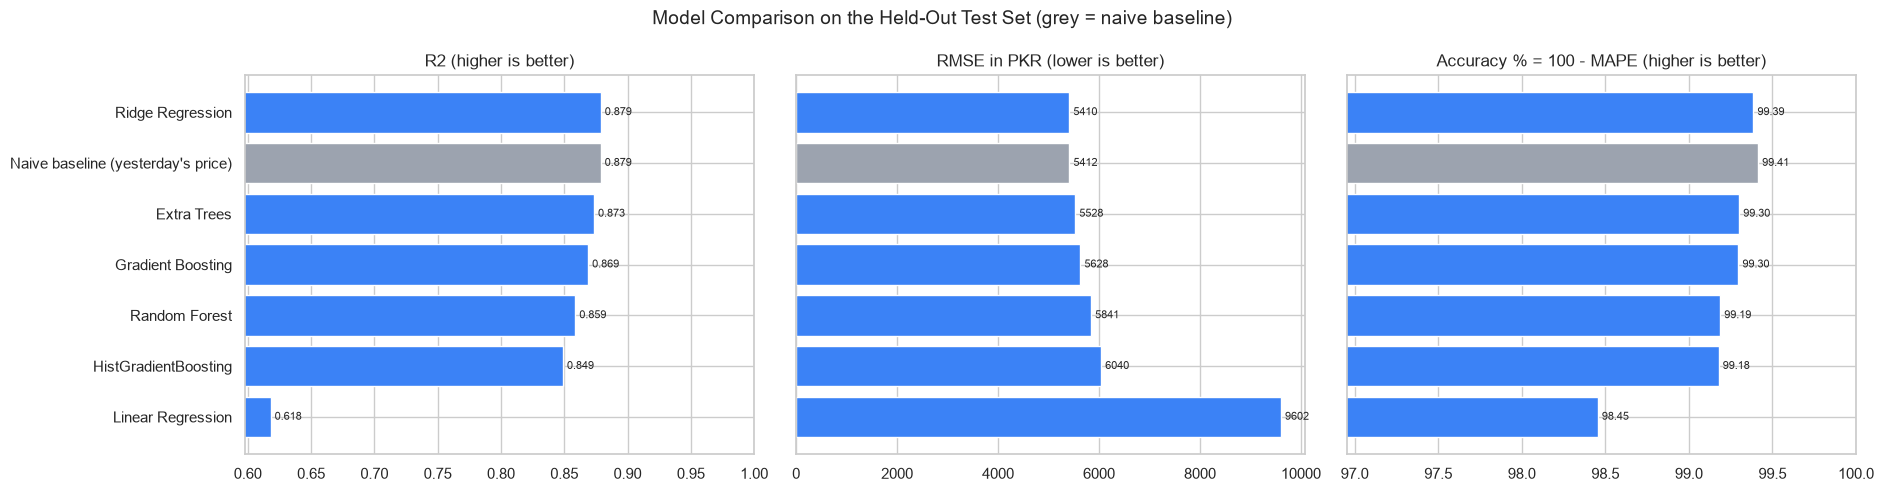

In [29]:
# ---------------- Model comparison chart ----------------
plot_df = comparison.copy()
colors = ["#9ca3af" if t == "Baseline" else "#3b82f6" for t in plot_df["Type"]]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
panels = [("R2 Score", "R2 (higher is better)", "%.3f"),
          ("RMSE (PKR)", "RMSE in PKR (lower is better)", "%.0f"),
          ("Accuracy (%)", "Accuracy % = 100 - MAPE (higher is better)", "%.2f")]

for ax, (col, title, fmt) in zip(axes, panels):
    ax.barh(plot_df["Model"], plot_df[col], color=colors)
    ax.bar_label(ax.containers[0], fmt=fmt, padding=3, fontsize=8)
    ax.set_title(title)
    ax.invert_yaxis()
    low = plot_df[col].min()
    if col == "Accuracy (%)":
        ax.set_xlim(max(0, low - 1.5), 100)
    elif col == "R2 Score":
        ax.set_xlim(low - 0.02 if low >= 0.5 else min(0.0, low), 1.0)
axes[1].set_yticklabels([])
axes[2].set_yticklabels([])
fig.suptitle("Model Comparison on the Held-Out Test Set (grey = naive baseline)", fontsize=14)
plt.tight_layout()
plt.show()

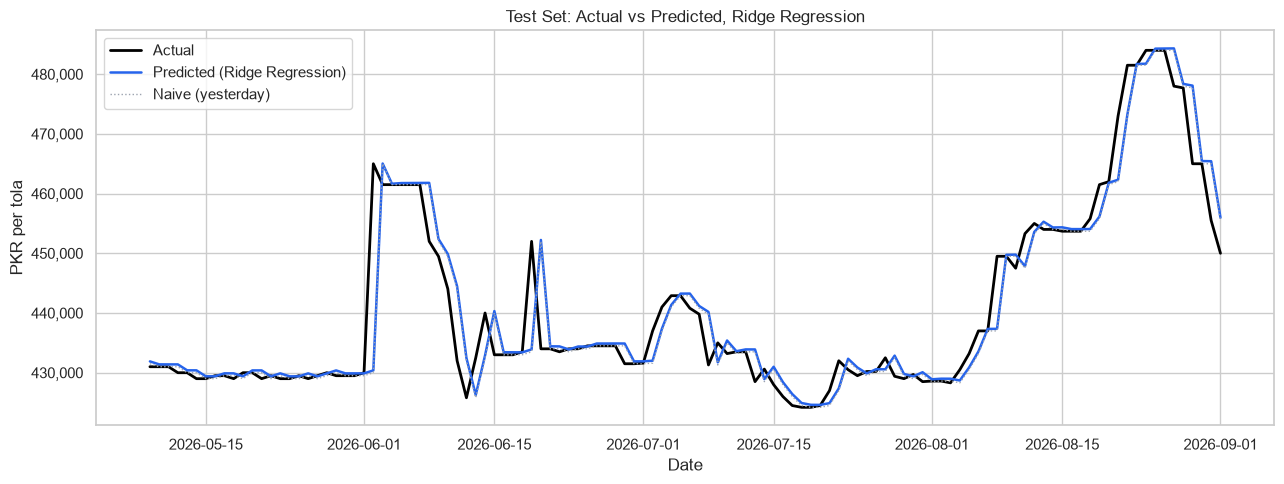

In [30]:
# ---------------- Actual vs predicted for the best model ----------------
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test["Date"], price_test, lw=2, color="black", label="Actual")
ax.plot(test["Date"], test_preds[best_name], lw=1.8, color="#2563eb", label=f"Predicted ({best_name})")
ax.plot(test["Date"], lag1_test, lw=1, ls=":", color="#9ca3af", label="Naive (yesterday)")
ax.set(title=f"Test Set: Actual vs Predicted, {best_name}", xlabel="Date", ylabel="PKR per tola")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend()
plt.tight_layout()
plt.show()

## 5. 30-day recursive forecast

The best model is re-fitted on **all** available history, then forecasts one day at a time. Each predicted price is appended to the history so it feeds the next day's lags, moving averages and volatility.

The shaded band is an approximate 95 % interval built from the model's held-out daily error, widened by `sqrt(days ahead)`. Recursive forecasts of a series this random are naturally flat-ish with wide uncertainty; the band shows how quickly confidence decays.

In [31]:
final_model = clone(best_model)
final_model.fit(feat[MODEL_FEATURES], feat["Target_LogReturn"])

# Daily error scale measured on the untouched test window
sigma = float(np.std(y_test.values - best_model.predict(X_test), ddof=1))

history = df[TARGET].astype(float).tolist()
last_date = df["Date"].max()
forecast_rows = []

for h in range(1, FORECAST_DAYS + 1):
    next_date = last_date + pd.Timedelta(days=h)
    X_next = build_feature_row(history, next_date)[MODEL_FEATURES]
    pred_return = float(final_model.predict(X_next)[0])
    pred_price = history[-1] * math.exp(pred_return)
    history.append(pred_price)                       # recursion: today's forecast becomes tomorrow's lag

    band = 1.96 * sigma * math.sqrt(h)
    forecast_rows.append({
        "Date": next_date,
        "Day_Ahead": h,
        "Forecast_24K_PKR_per_Tola": round(pred_price, 2),
        "Lower_95": round(pred_price * math.exp(-band), 2),
        "Upper_95": round(pred_price * math.exp(band), 2),
    })

forecast_df = pd.DataFrame(forecast_rows)
print(f"Model: {best_name} | last data date: {last_date.date()} | forecast: "
      f"{forecast_df['Date'].min().date()} -> {forecast_df['Date'].max().date()}")
forecast_df

Model: Ridge Regression | last data date: 2026-09-01 | forecast: 2026-09-02 -> 2026-10-01


,Date,Day_Ahead,Forecast_24K_PKR_per_Tola,Lower_95,Upper_95
0,2026-09-02,1,450367.35,439782.81,461206.62
1,2026-09-03,2,450723.76,435816.38,466141.06
2,2026-09-04,3,451083.75,432879.93,470053.09
3,2026-09-05,4,451448.49,430477.96,473440.59
4,2026-09-06,5,451812.87,428413.41,476490.38
5,2026-09-07,6,452176.17,426587.15,479300.15
6,2026-09-08,7,452538.70,424941.07,481928.64
7,2026-09-09,8,452900.92,423437.58,484414.36
8,2026-09-10,9,453263.37,422050.77,486784.28
9,2026-09-11,10,453627.02,420762.36,489058.65


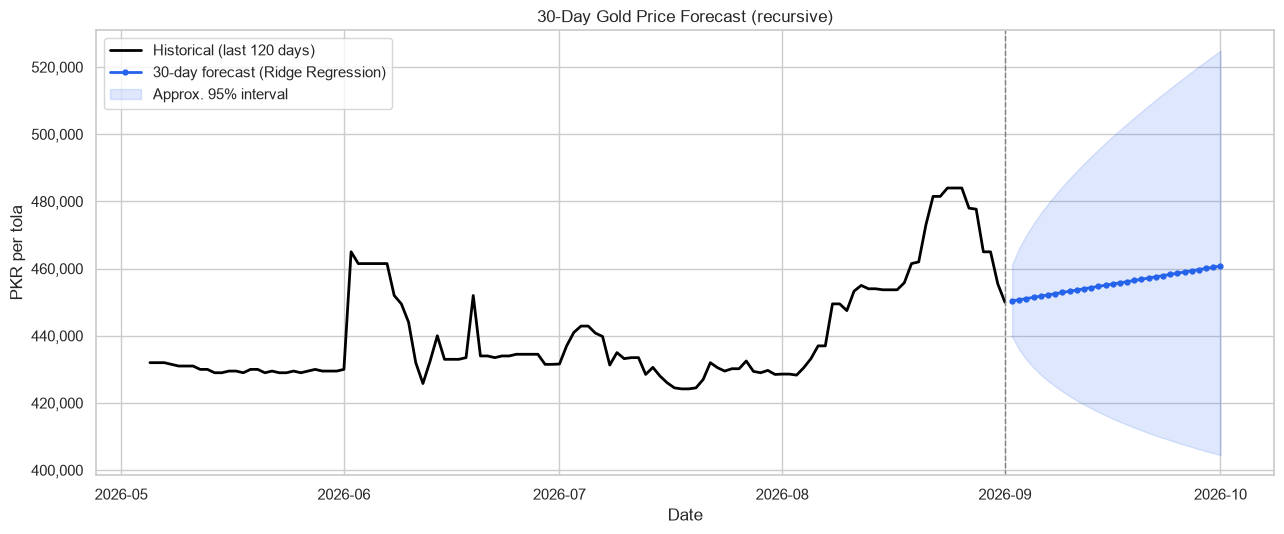

In [32]:
hist_tail = df.tail(120)
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(hist_tail["Date"], hist_tail[TARGET], lw=2, color="black", label="Historical (last 120 days)")
ax.plot(forecast_df["Date"], forecast_df["Forecast_24K_PKR_per_Tola"], lw=2, color="#2563eb",
        marker="o", markersize=3.5, label=f"30-day forecast ({best_name})")
ax.fill_between(forecast_df["Date"], forecast_df["Lower_95"], forecast_df["Upper_95"],
                color="#2563eb", alpha=0.15, label="Approx. 95% interval")
ax.axvline(last_date, color="grey", ls="--", lw=1)
ax.set(title="30-Day Gold Price Forecast (recursive)", xlabel="Date", ylabel="PKR per tola")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 6. Export to Excel

`Pakistan_Gold_30_Day_ML_Final.xlsx` is written next to this notebook and contains: cleaned data, the full feature set, dropped columns, model comparison, best hyperparameters, test-set predictions for every model, and the 30-day forecast.

In [33]:
def dates_only(frame):
    frame = frame.copy()
    frame["Date"] = pd.to_datetime(frame["Date"]).dt.date
    return frame


clean_out = dates_only(df[["Date", TARGET]])

feature_out = dates_only(
    feat[["Date", TARGET] + RAW_FEATURES + REL_FEATURES + ["Target_LogReturn"]]
)

test_out = pd.DataFrame({"Date": test["Date"].values, "Actual_Price": price_test})
for name, pred in test_preds.items():
    test_out[f"Pred_{name}"] = pred
test_out["Best_Model_Predicted"] = test_preds[best_name]
test_out["Best_Model_Error_PKR"] = test_out["Best_Model_Predicted"] - test_out["Actual_Price"]
test_out["Best_Model_Abs_Pct_Error"] = (test_out["Best_Model_Error_PKR"].abs() / test_out["Actual_Price"]) * 100
test_out = dates_only(test_out)

comparison_out = comparison.copy()
comparison_out["Selected_Best"] = np.where(comparison_out["Model"] == best_name, "YES", "")

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    clean_out.to_excel(writer, sheet_name="Clean_Data", index=False)
    feature_out.to_excel(writer, sheet_name="Feature_Set", index=False)
    dropped_df.to_excel(writer, sheet_name="Dropped_Columns", index=False)
    comparison_out.to_excel(writer, sheet_name="Model_Comparison", index=False)
    params_df.to_excel(writer, sheet_name="Best_Hyperparameters", index=False)
    test_out.to_excel(writer, sheet_name="Test_Predictions", index=False)
    dates_only(forecast_df).to_excel(writer, sheet_name="30_Day_Forecast", index=False)

    # light formatting
    from openpyxl.styles import Font, PatternFill, Alignment
    header_fill = PatternFill("solid", fgColor="1F2937")
    for ws in writer.book.worksheets:
        ws.freeze_panes = "A2"
        for cell in ws[1]:
            cell.font = Font(bold=True, color="FFFFFF")
            cell.fill = header_fill
            cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
        for col_cells in ws.columns:
            longest = max(len(str(c.value)) if c.value is not None else 0 for c in col_cells[:200])
            ws.column_dimensions[col_cells[0].column_letter].width = min(max(12, longest + 2), 60)
        for row in ws.iter_rows(min_row=2):
            for c in row:
                if isinstance(c.value, float):
                    c.number_format = "#,##0.0000" if abs(c.value) < 10 else "#,##0.00"

print("Saved:", Path(OUTPUT_XLSX).resolve())
print("Sheets:", [ws.title for ws in writer.book.worksheets])

PermissionError: [Errno 13] Permission denied: 'Pakistan_Gold_30_Day_ML_Final.xlsx'

In [ ]:
print("=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Best model        : {best_name}")
print(f"Test R2           : {best['R2 Score']:.4f}")
print(f"Test Accuracy     : {best['Accuracy (%)']:.3f}%   (100 - MAPE)")
print(f"Test MAE / RMSE   : {best['MAE (PKR)']:,.0f} / {best['RMSE (PKR)']:,.0f} PKR")
print(f"Naive baseline R2 : {base['R2 Score']:.4f}")
print(f"Forecast window   : {forecast_df['Date'].min().date()} -> {forecast_df['Date'].max().date()}")
print(f"Day 30 forecast   : {forecast_df['Forecast_24K_PKR_per_Tola'].iloc[-1]:,.0f} PKR "
      f"(95% band {forecast_df['Lower_95'].iloc[-1]:,.0f} - {forecast_df['Upper_95'].iloc[-1]:,.0f})")
print(f"Excel output      : {OUTPUT_XLSX}")